In [1]:
import torch
from torch import nn

torch.__version__

'2.12.1+cu130'

In [2]:
device = "cuda" if torch.cuda.is_available() else "illada kutta"
print(device)

cuda


In [3]:
!nvidia-smi

Mon Jul  6 20:06:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P8              2W /   65W |       5MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import requests
import zipfile
from pathlib import Path

#setup path to the data folder

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesnt exist, downoad it and prepare it...
if image_path.is_dir():
  print(f"{image_path}directory is already existing..skipping downlaoding")
else:
  print(f"No {image_path}. Creating one.....")
  image_path.mkdir(parents=True, exist_ok=True)



data/pizza_steak_sushidirectory is already existing..skipping downlaoding


In [5]:
# downlad pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading Pizza, steak and sushi data..")
  f.write(request.content)

In [6]:
# unzip, lets fuckin do it
with zipfile.ZipFile("/home/ash/FoodVision/data/pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping 3 of the data")
  zip_ref.extractall(image_path)

Unzipping 3 of the data


In [7]:
image_path

PosixPath('data/pizza_steak_sushi')

## 2. Becoming one with the data (Data preparation and data exploration)

In [8]:
import os
def walk_through_dir(dir_path):
  """ Walks through dir_path returning its contents. """

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [9]:
walk_through_dir(image_path)


There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi


In [10]:
# setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image


writing code to:
1. Get all the image paths

2.Pick a random image path using py random.choice()

3.Get the image class name

4. open the image with pythons pillow

5. show the image and print the metadata

Random image path is data/pizza_steak_sushi/train/sushi/748830.jpg
Image class is sushi
Image height: 287
Image width: 512


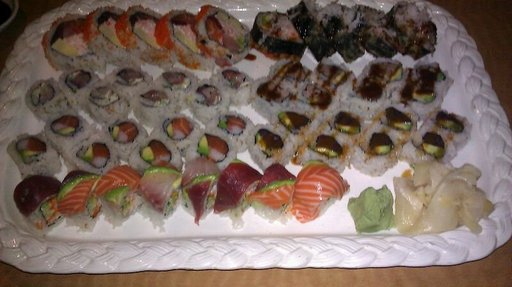

In [11]:
import random
from PIL import Image

#set seed
#random.seed(42)

#1. get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

#2. Pick a random image path
random_image_path = random.choice(image_path_list)

#3. Get the image class name
image_class = random_image_path.parent.stem

#4. Openup the image
img = Image.open(random_image_path)

#5. printing the metadata
print(f"Random image path is {random_image_path}")
print(f"Image class is {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

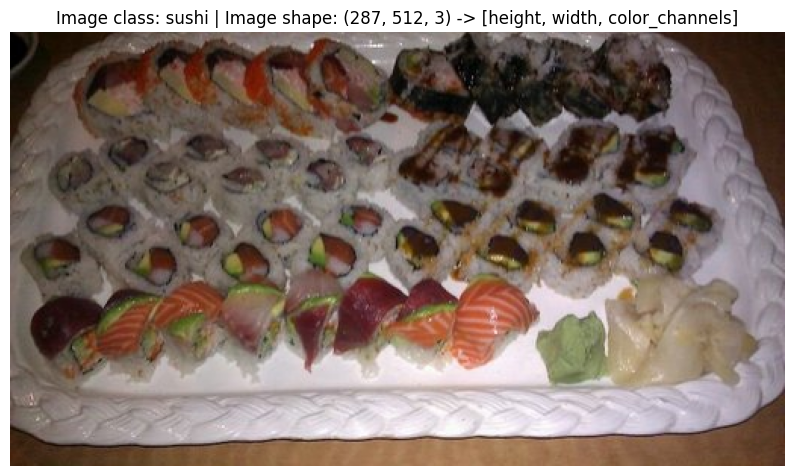

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)


#Plotting the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

##3. Transforming data

Before we can us e the img data with pytorch:
1. Turn your target data into tensors
2. Turn it into a torch.utils.data.Dataset and torch.utils.data.DataLoader, well call these dataset and dataloader

In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with  'torchvision.transforms'

In [14]:
# writing a tansform for image
data_transform = transforms.Compose([
    #resizing our images to 64x64
    transforms.Resize(size=(64, 64)),
    #Flipping the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), #augmentation to create more diversity among data
    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [15]:
data_transform(img)

tensor([[[0.0863, 0.1412, 0.1294,  ..., 0.1451, 0.1373, 0.1373],
         [0.0196, 0.1098, 0.1294,  ..., 0.1490, 0.1333, 0.1294],
         [0.0039, 0.0902, 0.0980,  ..., 0.1569, 0.1490, 0.1412],
         ...,
         [0.2510, 0.2392, 0.2549,  ..., 0.3608, 0.3608, 0.3490],
         [0.2745, 0.2471, 0.2510,  ..., 0.3843, 0.3765, 0.3490],
         [0.2588, 0.2549, 0.2392,  ..., 0.3961, 0.3765, 0.3373]],

        [[0.0627, 0.1098, 0.0863,  ..., 0.0863, 0.0745, 0.0706],
         [0.0118, 0.0902, 0.0863,  ..., 0.0824, 0.0784, 0.0745],
         [0.0039, 0.0706, 0.0784,  ..., 0.0863, 0.0863, 0.0784],
         ...,
         [0.1451, 0.1451, 0.1569,  ..., 0.2353, 0.2353, 0.2157],
         [0.1490, 0.1490, 0.1569,  ..., 0.2471, 0.2471, 0.2196],
         [0.1451, 0.1529, 0.1569,  ..., 0.2471, 0.2431, 0.2118]],

        [[0.0471, 0.0667, 0.0353,  ..., 0.0275, 0.0353, 0.0392],
         [0.0118, 0.0588, 0.0431,  ..., 0.0392, 0.0392, 0.0392],
         [0.0039, 0.0510, 0.0353,  ..., 0.0392, 0.0392, 0.

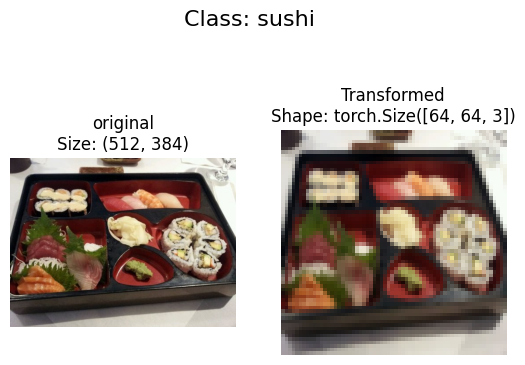

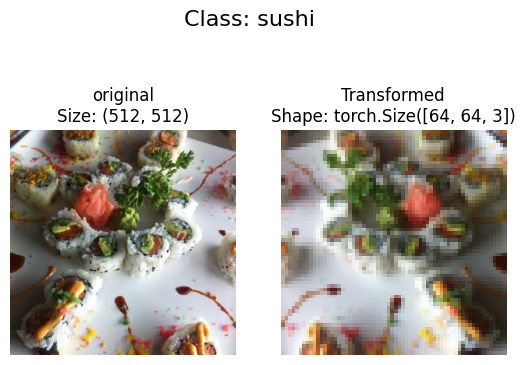

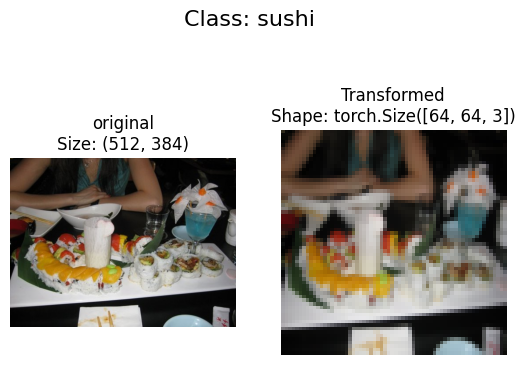

In [16]:
def plot_transformed_images(image_paths, transform, n=3, seed = None):
  """
  Selects random images from a path of images and loads/transfors them then plots the original vs the transformed version
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f).permute(1, 2, 0) # we will need to change shape for matplotlib (c,H,W) -> (H,W,C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,n=3,seed=None)

In [17]:
### 4. Option 1: Loading image data using ImageFolder
# Use ImageFolder to create dataset()
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None) # a transform for the label/target
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)
train_data, test_data


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [18]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [19]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [20]:
#Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [21]:
#Checking the lengths of our dataset
len(train_data), len(test_data)

(225, 75)

In [22]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [23]:
## Index on the train_data dataset to get a single image and label
img, label = train_data[0][0], train_data[0][1]
print(f"Image tensor:\n {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label:{label} ")
print(f"Label datatypes: {type(label)}")

Image tensor:
 tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permmuted: torch.Size([64, 64, 3]) -> [height,width, color_channels]


Text(0.5, 1.0, 'pizza')

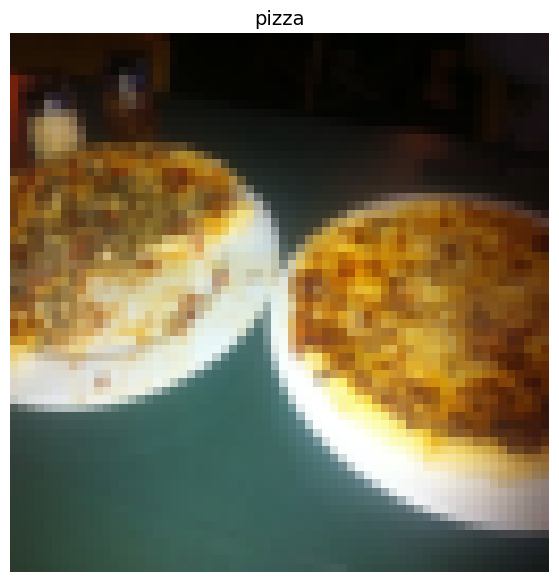

In [24]:
# Rearrange the order of dimensions because matplotlib dimensions colour channels are at last
img_permute = img.permute(1,2,0)

#Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permmuted: {img_permute.shape} -> [height,width, color_channels]")

# Plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize=14)

In [25]:
import os
os.cpu_count()

16

In [26]:
## 4.1 Turn loaded image into 'Dataloader
from torch.utils.data import DataLoader
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=os.cpu_count())
test_dataloader = DataLoader(dataset = test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7f4c6996b8b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7f4c6996a3b0>)

In [27]:
len(train_dataloader), len(test_dataloader)

(225, 75)

In [28]:
img, label = next(iter(train_dataloader))

print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([1, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([1])


In [29]:
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [30]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [31]:
# 5.1 creating a helper function to  get class name

# setup path for targert dir
target_directory = train_dir
print(f"Target dir: {target_directory}")

#getting the class names from the target dir
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [32]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [33]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in a target directory."""
  # 1. Get the class names by scanning the target dir
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  # 2. Raising an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldnt find any classes in {directory}...")
  #3. Create a dictionary of index labels
  class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
  return classes, class_to_idx

In [34]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [35]:
# Write a custom dataset class (inherits from torch.utils.data.Dataset)
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    
    # 2. Initialize with a targ_dir and transform (optional) parameter
    def __init__(self, targ_dir: str, transform=None) -> None:
        
        # 3. Create class attributes
        # Get all image paths
        self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(targ_dir)

    # 4. Make function to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it."
        image_path = self.paths[index]
        return Image.open(image_path) 
    
    # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
    def __len__(self) -> int:
        "Returns the total number of samples."
        return len(self.paths)
    
    # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X, y)."
        img = self.load_image(index)
        class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else:
            return img, class_idx # return data, label (X, y)

In [36]:
# Augment train data
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Don't augment test data, only reshape
test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [37]:
import pathlib

In [38]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, 
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, 
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7f4c697eca30>,
 <__main__.ImageFolderCustom at 0x7f4c697ed900>)

In [39]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir, 
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir, 
                                     transform=test_transforms)
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7f4c69609270>,
 <__main__.ImageFolderCustom at 0x7f4c697efee0>)

In [40]:
len(train_data), len(train_data_custom)

(225, 225)

In [41]:
len(test_data), len(test_data_custom)

(75, 75)

In [42]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [43]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [44]:
# Check for equality between original Imagefolder and imagefoldercustom dataset
print(train_data_custom.classes==train_data.classes)
print(test_data.classes == test_data_custom.classes)

True
True


### 5.3 Creating a function to display random images
1. Take in a `dataset` and a no of other parameter such as class names and how mnay images to visualize
2. To prevent the display getting out of hand, lets cap the no of images to see at 10
3. Setting the random seed for reproducibiliy
4. Get a list of random sample indexes from the target dataset
5. Setup a matplotlib plot
6. Looping through the random sample images and plot them with matplotlib
7. Make sure the dimensions of our images line up with the matplotlib

In [49]:
# 1. creating a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    # 2. Adjust display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display, purposes, n shouldn't be larger than 10, setting to 10 and removing shape display")
    # 3. Setting the seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    #5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Looping through random indexes and plot them with matplotlib
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensipons for plotting
    targ_image_adjust = targ_image.permute(1, 2, 0) # [color_channels, height, width] -> [height, width, color_channels]

    # Plot adjusted samples
    plt.Subplot(1,n,i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("Off")
    if classes:
        title = f"Class: {classes[targ_label]}"
        if display_shape:
            title = title + f"\nShape: {targ_image_adjust.shape}"
        plt.title(title) 

[209, 32, 88, 199, 186, 61, 132, 33, 219, 194]